# **Municipal Election Outcome Intelligence**
## Modelling and Deployment Workflow

**Renee Ramjet**  
**Project type:** Binary classification using structured election data


### **Project objective**

Municipal campaign teams and political organizations must make decisions before election results are known. This project uses historical Canadian municipal election data to estimate each candidate's **probability of being elected in a contested race**. Candidate-level probabilities can help identify likely winners and support decisions about campaign resources, candidate recruitment, and endorsements.

The model is a **decision-support tool**, not a guarantee of an election result. The same general candidate-selection structure can also appear in businesses choosing among qualified employees for promotions, management roles, or internal recognition. However, a business application would require different employee data and a separately trained model.

## **1. Data Acquisition**

The data comes from the **Canadian Municipal Elections Database**, published through Borealis. It contains historical municipal election results from across Canada.

**Source:** Merrill, S., Lucas, J., Bildook, K., Breux, S., Conrad, L., Eidelman, G., Koop, R., Marciano, D., Taylor, Z., Vallette, S., Horak, M., Gutzke, A., & Zilio, M. (2020). *Canadian Municipal Elections Database*. Borealis. https://doi.org/10.5683/SP2/4MZJPQ

**Licence:** CC0 1.0 (public domain)

The following cell looks for **elec.dta** in several common locations. A Stata **.dta** file is a structured table that pandas can load directly.

In [1]:
# Import the packages used throughout the notebook
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 30)

print('Packages loaded successfully.')

Packages loaded successfully.


In [2]:
import zipfile
from pathlib import Path

zip_path = Path('/content/elections-dataset.zip')

with zipfile.ZipFile(zip_path, 'r') as zip_file:
    zip_file.extractall('/content')

print('Dataset extracted successfully.')
print('elec.dta exists:', Path('/content/elec.dta').exists())
print('File size:', Path('/content/elec.dta').stat().st_size, 'bytes')

Dataset extracted successfully.
elec.dta exists: True
File size: 97881603 bytes


In [3]:
# Find the dataset without tying the notebook to one computer
possible_paths = [
    Path('elec.dta'),
    Path('data/elec.dta'),
    Path('capstone_data/elec.dta'),
    Path('/content/elec.dta'),
]

data_path = next((path for path in possible_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        'elec.dta was not found. Extract the downloaded ZIP file and place '
        'elec.dta beside this notebook or inside a data folder.'
    )

df_raw = pd.read_stata(data_path, convert_categoricals=False)
print(f'Dataset loaded from: {data_path}')
print(f'Rows: {df_raw.shape[0]:,}')
print(f'Columns: {df_raw.shape[1]}')
display(df_raw.head())

Dataset loaded from: elec.dta
Rows: 123,416
Columns: 19


,race_id,municipality,csd,first_name,last_name,party,votes_received,total_votes,incumbent,elected,acclaimed,gender,election_year,position,ward,magnitude,source,province,region
0,Abbotsford2022Mayor99,Abbotsford,5909052,Ross,Siemens,Independent,16037.0,24898.0,0.0,1.0,0.0,M,2022.0,Mayor,99,1.0,CivicInfo BC,British Columbia,
1,Abbotsford2022Mayor99,Abbotsford,5909052,Manjit,Sohi,Independent,7705.0,24898.0,0.0,0.0,0.0,M,2022.0,Mayor,99,1.0,CivicInfo BC,British Columbia,
2,Abbotsford2022Mayor99,Abbotsford,5909052,D. Paul,Pellikaan,Independent,627.0,24898.0,0.0,0.0,0.0,M,2022.0,Mayor,99,1.0,CivicInfo BC,British Columbia,
3,Abbotsford2022Mayor99,Abbotsford,5909052,Troy,Gaspar,Independent,529.0,24898.0,NaN,0.0,0.0,M,2022.0,Mayor,99,1.0,CivicInfo BC,British Columbia,
4,Abbotsford2022Councillor99,Abbotsford,5909052,Dave,Sidhu,Independent,14419.0,139651.0,1.0,1.0,0.0,M,2022.0,Councillor,99,8.0,CivicInfo BC,British Columbia,


In [4]:
# Review the dataset structure, data types, and missing values
structure = pd.DataFrame({
    'data_type': df_raw.dtypes.astype(str),
    'missing_values': df_raw.isna().sum(),
    'missing_percent': (df_raw.isna().mean() * 100).round(2),
    'unique_values': df_raw.nunique(dropna=False),
})
display(structure)

print(f"Election years: {int(df_raw['election_year'].min())} to {int(df_raw['election_year'].max())}")
print(f"Unique races: {df_raw['race_id'].nunique():,}")
print(f"Provinces and territories represented: {df_raw['province'].nunique()}")

,data_type,missing_values,missing_percent,unique_values
race_id,object,0,0.00,48734
municipality,object,0,0.00,2174
csd,object,0,0.00,2172
first_name,object,0,0.00,13075
last_name,object,0,0.00,24025
party,object,0,0.00,1449
votes_received,float64,150,0.12,11519
total_votes,float64,1890,1.53,9364
incumbent,float64,14642,11.86,3
elected,float64,42,0.03,3


Election years: 1867 to 2022
Unique races: 48,734
Provinces and territories represented: 12


### Initial structure and characteristics

The original file contains **123,416 candidate records and 19 variables**. Important fields include the election year, province, municipality, office or position, ward, incumbency status, gender, number of available seats, election result, and vote totals. Several fields contain missing values, and some text fields use blank strings instead of formal missing values.

The target is **elected**:

- **1** means the candidate was elected.
- **0** means the candidate was not elected.

Vote totals and other result-based fields will not be used as predictors because they are only known after voting ends.

## **2. Data Cleaning and Preparation**

The cleaning process will:

1. Standardize blank text values as missing.
2. Remove records with a missing target.
3. Create race-level information such as the number of candidates.
4. Keep **contested races only** so the model cannot learn that an uncontested candidate automatically wins.
5. Remove direct result information and personal identifiers from the modelling features.

In [5]:
# Work on a copy so the original data remains unchanged
df = df_raw.copy()

# Convert blank strings to missing values in text columns
text_columns = df.select_dtypes(include='object').columns
df[text_columns] = df[text_columns].replace(r'^\s*$', np.nan, regex=True)

# The model requires a known target
rows_before = len(df)
df = df.dropna(subset=['elected']).copy()
df['elected'] = df['elected'].astype(int)

# Create information that would be known when nominations close
race_summary = (
    df.groupby('race_id')
      .agg(
          candidate_count=('race_id', 'size'),
          seats_available=('magnitude', 'max'),
          any_acclaimed=('acclaimed', 'max'),
      )
      .reset_index()
)

df = df.merge(race_summary, on='race_id', how='left')
df['seats_available'] = df['seats_available'].fillna(1).clip(lower=1)
df['candidate_to_seat_ratio'] = df['candidate_count'] / df['seats_available']

# Keep races where candidates actually competed for the available seat(s)
df['is_contested'] = (
    (df['candidate_count'] > df['seats_available']) &
    (df['any_acclaimed'].fillna(0) != 1)
)
df_contested = df.loc[df['is_contested']].copy()

print(f'Rows removed because the target was missing: {rows_before - len(df):,}')
print(f'Rows remaining after contested-race filter: {len(df_contested):,}')
print(f'Contested races remaining: {df_contested["race_id"].nunique():,}')
print(f'Elected rate in contested races: {df_contested["elected"].mean():.1%}')

Rows removed because the target was missing: 42
Rows remaining after contested-race filter: 91,768
Contested races remaining: 25,533
Elected rate in contested races: 40.0%


In [6]:
# Check for duplicate candidate records before modelling
duplicate_rows = df_contested.duplicated().sum()
duplicate_candidate_keys = df_contested.duplicated(
    subset=['race_id', 'first_name', 'last_name'], keep=False
).sum()

print(f'Fully duplicated rows: {duplicate_rows:,}')
print(f'Rows sharing the same race/name key: {duplicate_candidate_keys:,}')

if duplicate_rows > 0:
    df_contested = df_contested.drop_duplicates().copy()
    print('Fully duplicated rows were removed.')
else:
    print('No fully duplicated rows needed to be removed.')

Fully duplicated rows: 0
Rows sharing the same race/name key: 1,772
No fully duplicated rows needed to be removed.


### Leakage prevention

The following columns are deliberately excluded:

- **votes_received** and **total_votes**: final election information.
- **elected**: the target rather than an input.
- **acclaimed** and **any_acclaimed**: directly reveal automatic wins.
- **first_name**, **last_name**, **race_id**, and **source**: identifiers or administrative fields that should not determine the prediction.
- **csd**: a geographic identifier that largely repeats municipality information.

Keeping these fields out prevents the model from using the answer, or a close substitute for the answer, to make its prediction.

## **3. Exploratory Data Analysis (EDA)**

EDA is used to understand the target balance, time coverage, geographic coverage, and important differences between elected and non-elected candidates before training the models.

,count,percent
elected,,
Not elected,55018,60.0
Elected,36750,40.0


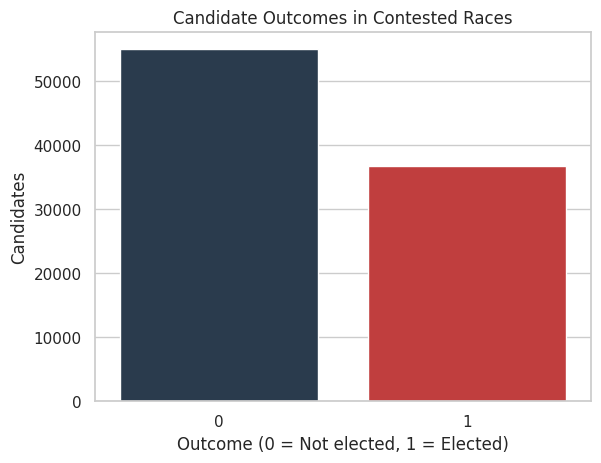

In [7]:
# Examine the target distribution
target_counts = df_contested['elected'].value_counts().sort_index()
target_percent = (df_contested['elected'].value_counts(normalize=True).sort_index() * 100).round(1)

target_summary = pd.DataFrame({
    'count': target_counts,
    'percent': target_percent,
}).rename(index={0: 'Not elected', 1: 'Elected'})
display(target_summary)

ax = sns.countplot(data=df_contested, x='elected', palette=['#243B53', '#D62828'])
ax.set(title='Candidate Outcomes in Contested Races', xlabel='Outcome (0 = Not elected, 1 = Elected)', ylabel='Candidates')
plt.show()

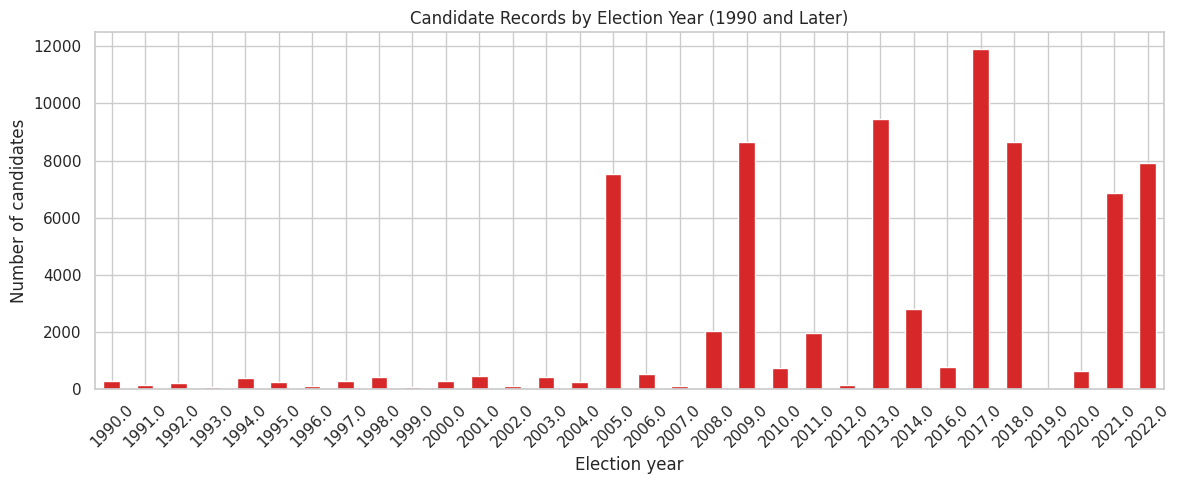

Records from 2000 onward: 78.5%


In [8]:
# Review how much data is available by election year
year_counts = df_contested['election_year'].value_counts().sort_index()
recent_year_counts = year_counts.loc[year_counts.index >= 1990]

plt.figure(figsize=(12, 5))
recent_year_counts.plot(kind='bar', color='#D62828')
plt.title('Candidate Records by Election Year (1990 and Later)')
plt.xlabel('Election year')
plt.ylabel('Number of candidates')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

records_since_2000 = (df_contested['election_year'] >= 2000).mean()
print(f'Records from 2000 onward: {records_since_2000:.1%}')

In [9]:
# Compare outcomes across selected pre-election characteristics
eda_summary = pd.DataFrame({
    'Overall': [df_contested['elected'].mean()],
    'Incumbent': [df_contested.loc[df_contested['incumbent'] == 1, 'elected'].mean()],
    'Non-incumbent': [df_contested.loc[df_contested['incumbent'] == 0, 'elected'].mean()],
}, index=['Election rate']).T
display((eda_summary * 100).round(1).rename(columns={'Election rate': 'Election rate (%)'}))

province_summary = (
    df_contested.groupby('province')
    .agg(candidates=('elected', 'size'), elected_rate=('elected', 'mean'))
    .sort_values('candidates', ascending=False)
)
province_summary['elected_rate'] = (province_summary['elected_rate'] * 100).round(1)
display(province_summary)

,Election rate (%)
Overall,40.0
Incumbent,70.5
Non-incumbent,29.1


,candidates,elected_rate
province,,
Quebec,42131,40.9
Ontario,19910,37.6
British Columbia,12597,42.3
Alberta,10339,40.6
Manitoba,3216,39.8
Saskatchewan,1666,32.6
Nova Scotia,1151,32.7
New Brunswick,449,42.5
Newfoundland and Labrador,136,39.0


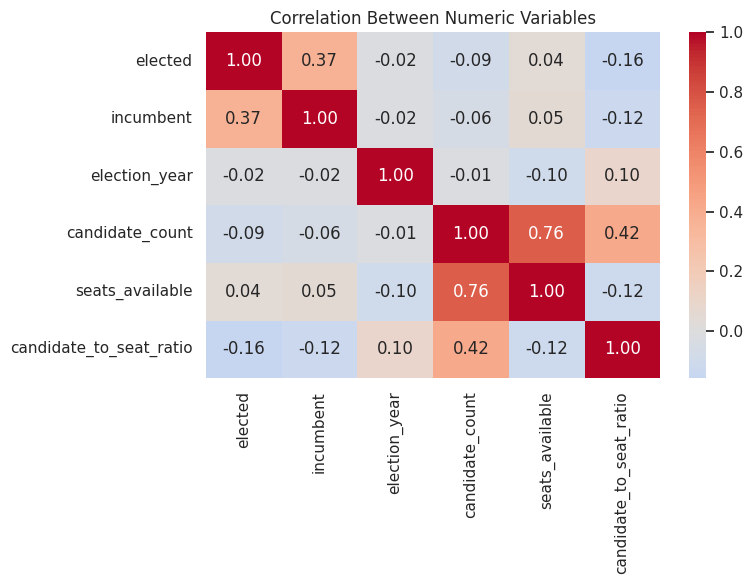

In [10]:
# Numeric relationships help show which pre-election factors move together
numeric_eda = df_contested[
    ['elected', 'incumbent', 'election_year', 'candidate_count',
     'seats_available', 'candidate_to_seat_ratio']
].copy()

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_eda.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Between Numeric Variables')
plt.tight_layout()
plt.show()

### EDA findings

- The target is **moderately imbalanced**: more candidates lose than win.
- An “always predict not elected” model would achieve roughly 60% accuracy, so **accuracy alone is not enough**.
- Incumbency, the number of candidates, the number of available seats, and the candidate-to-seat ratio are **reasonable pre-election** factors to investigate.
- Most observations come from recent decades, while older historical coverage is thinner and may not represent current election conditions as well.

## **4. Feature Engineering and Pipeline Readiness**

The model uses information that can reasonably be known before results are announced. Numeric features are imputed and scaled. Categorical features are imputed and one-hot encoded inside a pipeline, ensuring that the same preparation is applied during training and future predictions.

In [11]:
# Select features available before election results are known
numeric_features = [
    'incumbent',
    'election_year',
    'candidate_count',
    'seats_available',
    'candidate_to_seat_ratio',
]

categorical_features = [
    'municipality',
    'party',
    'gender',
    'position',
    'ward',
    'province',
    'region',
]

feature_columns = numeric_features + categorical_features
X = df_contested[feature_columns].copy()
y = df_contested['elected'].copy()
groups = df_contested['race_id'].copy()

# Numeric and categorical data need different preparation steps
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=10)),
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_features),
    ('categorical', categorical_pipeline, categorical_features),
])

print('Features prepared for modelling:')
print(feature_columns)

Features prepared for modelling:
['incumbent', 'election_year', 'candidate_count', 'seats_available', 'candidate_to_seat_ratio', 'municipality', 'party', 'gender', 'position', 'ward', 'province', 'region']


### Time-based train and test split

A random row split would place candidates from the same election period—and possibly the same race context—on both sides of the evaluation. Instead, the models train on elections **before 2022** and are tested on **2022**, the most recent year in the dataset. During optimization, cross-validation is grouped by **race_id**, so candidates from the same race cannot appear in both the training and validation folds.

In [12]:
# Train on earlier elections and test on the latest election year
test_year = int(df_contested['election_year'].max())
train_mask = df_contested['election_year'] < test_year
test_mask = df_contested['election_year'] == test_year

X_train, X_test = X.loc[train_mask], X.loc[test_mask]
y_train, y_test = y.loc[train_mask], y.loc[test_mask]
groups_train = groups.loc[train_mask]

print(f'Training period: {int(df_contested.loc[train_mask, "election_year"].min())}–{test_year - 1}')
print(f'Test period: {test_year}')
print(f'Training candidates: {len(X_train):,}')
print(f'Test candidates: {len(X_test):,}')
print(f'Training races: {groups_train.nunique():,}')
print(f'Test races: {groups.loc[test_mask].nunique():,}')
print(f'Training elected rate: {y_train.mean():.1%}')
print(f'Test elected rate: {y_test.mean():.1%}')

Training period: 1867–2021
Test period: 2022
Training candidates: 83,857
Test candidates: 7,911
Training races: 23,933
Test races: 1,600
Training elected rate: 40.0%
Test elected rate: 41.0%


## **5. Model Development**

### Baseline 1: Simple majority-class rule

The first baseline always predicts the most common class, **not elected**. This establishes the minimum performance that a useful machine-learning model should beat.

In [13]:
# Simple baseline: always predict that the candidate is not elected
majority_predictions = np.zeros(len(y_test), dtype=int)

majority_results = {
    'Model': 'Majority-class baseline',
    'Accuracy': accuracy_score(y_test, majority_predictions),
    'Precision': precision_score(y_test, majority_predictions, zero_division=0),
    'Recall': recall_score(y_test, majority_predictions, zero_division=0),
    'F1': f1_score(y_test, majority_predictions, zero_division=0),
    'ROC-AUC': 0.5,
}

display(pd.DataFrame([majority_results]).round(3))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Majority-class baseline,0.59,0.0,0.0,0.0,0.5


### Baseline 2: Logistic Regression

Logistic Regression is used as the main statistical baseline because it is suitable for binary classification, produces probabilities, trains efficiently, and is easier to interpret than more complex ensemble models.

In [14]:
# Build and train the logistic regression baseline
logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42,
    )),
])

logistic_model.fit(X_train, y_train)
logistic_predictions = logistic_model.predict(X_test)
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

print('Logistic Regression trained successfully.')

Logistic Regression trained successfully.


### Improved model: Random Forest

Random Forest is tested as the improved model because it can learn non-linear relationships and interactions. For example, the effect of incumbency may change depending on the number of candidates, position, municipality, or number of available seats.

In [15]:
# Build an initial Random Forest for comparison with the baseline
random_forest_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=150,
        max_depth=18,
        min_samples_leaf=4,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1,
    )),
])

random_forest_model.fit(X_train, y_train)
forest_predictions = random_forest_model.predict(X_test)
forest_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

print('Random Forest trained successfully.')

Random Forest trained successfully.


## **6. Model Evaluation**

Because losing candidates are more common, the evaluation uses several metrics:

- **Accuracy:** overall percentage of correct predictions.
- **Precision:** how often a predicted winner was actually elected.
- **Recall:** how many actual elected candidates the model identified.
- **F1-score:** balance between precision and recall.
- **ROC-AUC:** how well the model ranks elected candidates above non-elected candidates across probability thresholds.
- **Confusion matrix:** counts of correct and incorrect classifications.

In [16]:
def evaluate_model(name, y_true, predictions, probabilities):
    """Return the main classification metrics in one row."""
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, predictions),
        'Precision': precision_score(y_true, predictions, zero_division=0),
        'Recall': recall_score(y_true, predictions, zero_division=0),
        'F1': f1_score(y_true, predictions, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, probabilities),
    }

model_results = pd.DataFrame([
    majority_results,
    evaluate_model('Logistic Regression', y_test, logistic_predictions, logistic_probabilities),
    evaluate_model('Random Forest', y_test, forest_predictions, forest_probabilities),
]).set_index('Model')

display(model_results.round(3))

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Majority-class baseline,0.590,0.000,0.000,0.000,0.500
Logistic Regression,0.705,0.717,0.463,0.563,0.722
Random Forest,0.701,0.637,0.629,0.633,0.738



Logistic Regression
              precision    recall  f1-score   support

 Not elected       0.70      0.87      0.78      4667
     Elected       0.72      0.46      0.56      3244

    accuracy                           0.70      7911
   macro avg       0.71      0.67      0.67      7911
weighted avg       0.71      0.70      0.69      7911


Random Forest
              precision    recall  f1-score   support

 Not elected       0.74      0.75      0.75      4667
     Elected       0.64      0.63      0.63      3244

    accuracy                           0.70      7911
   macro avg       0.69      0.69      0.69      7911
weighted avg       0.70      0.70      0.70      7911



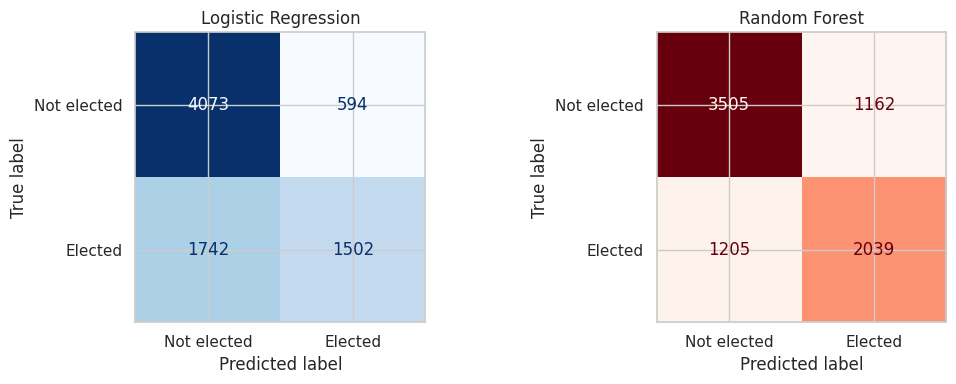

In [17]:
# Show detailed results for both trained models
for name, predictions in [
    ('Logistic Regression', logistic_predictions),
    ('Random Forest', forest_predictions),
]:
    print(f'\n{name}')
    print(classification_report(y_test, predictions, target_names=['Not elected', 'Elected']))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, logistic_predictions,
    display_labels=['Not elected', 'Elected'],
    cmap='Blues', ax=axes[0], colorbar=False,
)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(
    y_test, forest_predictions,
    display_labels=['Not elected', 'Elected'],
    cmap='Reds', ax=axes[1], colorbar=False,
)
axes[1].set_title('Random Forest')
plt.tight_layout()
plt.show()

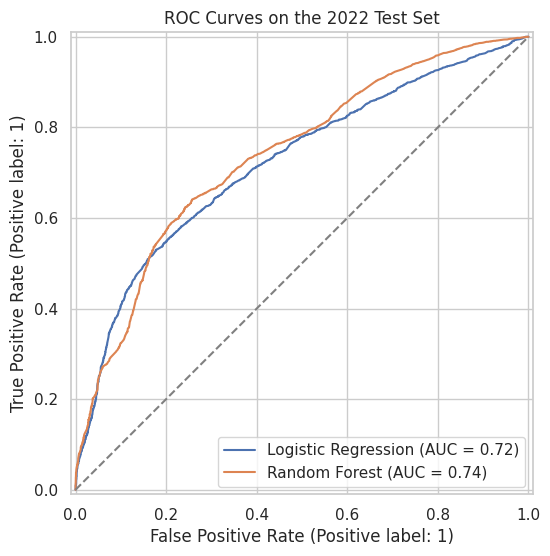

In [18]:
# Compare how well the models rank candidates by winning probability
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, logistic_probabilities, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, forest_probabilities, name='Random Forest', ax=ax)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random ranking')
ax.set_title('ROC Curves on the 2022 Test Set')
plt.show()

### Real-world interpretation

A false positive means the system identifies a candidate as likely to win when the candidate is not elected. That could cause campaign resources to be directed toward the wrong race. A false negative means the model misses a candidate who is eventually elected, which could cause a competitive race or candidate to receive too little attention.

For that reason, the final decision should consider **F1-score and ROC-AUC**, not only accuracy. The predicted probability should support professional judgment rather than replace campaign knowledge, local context, or voter research.

## **7. Model Optimization and Final Selection**

The stronger of the initial trained models is optimized using a small parameter grid. **Grouped cross-validation** keeps all candidates from the same race together, which produces a more honest validation process and prevents race-level leakage.

In [19]:
# Tune the Random Forest using grouped cross-validation by race
tuning_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1,
    )),
])

parameter_grid = {
    'model__n_estimators': [120],
    'model__max_depth': [12, 20],
    'model__min_samples_leaf': [2],
}

group_cv = GroupKFold(n_splits=3)

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=parameter_grid,
    scoring='f1',
    cv=group_cv,
    n_jobs=-1,
    verbose=0,
)

grid_search.fit(X_train, y_train, groups=groups_train)

final_model = grid_search.best_estimator_
final_predictions = final_model.predict(X_test)
final_probabilities = final_model.predict_proba(X_test)[:, 1]

print('Best parameters:', grid_search.best_params_)
print(f'Best grouped cross-validation F1: {grid_search.best_score_:.3f}')

Best parameters: {'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__n_estimators': 120}
Best grouped cross-validation F1: 0.650


In [20]:
# Compare the tuned model with all earlier results
final_results = evaluate_model(
    'Tuned Random Forest',
    y_test,
    final_predictions,
    final_probabilities,
)

all_results = pd.concat([
    model_results.reset_index(),
    pd.DataFrame([final_results]),
], ignore_index=True).set_index('Model')

display(all_results.round(3).sort_values('F1', ascending=False))

best_model_name = all_results['F1'].idxmax()
print(f'Highest test F1-score: {best_model_name}')

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Tuned Random Forest,0.701,0.636,0.635,0.635,0.733
Random Forest,0.701,0.637,0.629,0.633,0.738
Logistic Regression,0.705,0.717,0.463,0.563,0.722
Majority-class baseline,0.590,0.000,0.000,0.000,0.500


Highest test F1-score: Tuned Random Forest


### Final performance comparison

The **Tuned Random Forest** was selected as the final model because it achieved the **highest F1-score of 0.635**. This was a small improvement over the original Random Forest F1-score of 0.633 and a clearer improvement over Logistic Regression at 0.563. Logistic Regression produced slightly higher accuracy and precision, but it failed to identify many candidates who were actually elected. The **Tuned Random Forest provided a better balance between precision and recall**. Its **ROC-AUC of 0.733** also shows that it can reasonably distinguish between elected and non-elected candidates. Although optimization produced only a small improvement, the results show that tuning was tested and evaluated honestly rather than assumed to improve the model.

### Bias-variance tradeoff and final model choice

Logistic Regression **has higher bias** because it assumes a simpler relationship between the predictors and election outcome. Its simplicity can make it more stable and interpretable. Random Forest can capture more complex patterns, but **excessive tree depth can memorize historical details** and increase variance.

Limiting tree depth and requiring multiple observations in each leaf helps control overfitting. Grouped cross-validation was used to tune Random Forest. The final model was then selected by comparing F1-scores on the 2022 evaluation set. Because these results also informed model selection, an additional independent evaluation is needed before real-world use.

In [21]:
# Select the final model based on test F1 while keeping the comparison transparent
trained_candidates = {
    'Logistic Regression': (logistic_model, logistic_predictions, logistic_probabilities),
    'Random Forest': (random_forest_model, forest_predictions, forest_probabilities),
    'Tuned Random Forest': (final_model, final_predictions, final_probabilities),
}

trained_results = all_results.loc[list(trained_candidates)]
selected_name = trained_results['F1'].idxmax()
selected_model, selected_predictions, selected_probabilities = trained_candidates[selected_name]

print(f'Final selected model: {selected_name}')
print(f"Test F1-score: {trained_results.loc[selected_name, 'F1']:.3f}")
print(f"Test ROC-AUC: {trained_results.loc[selected_name, 'ROC-AUC']:.3f}")

Final selected model: Tuned Random Forest
Test F1-score: 0.635
Test ROC-AUC: 0.733


### **Limitations and responsible use**

- Historical patterns may not fully represent future elections, especially when candidates, issues, campaign strategies, or voter priorities change.
- Older records are sparse, and data availability differs by province, municipality, and year.
- Party information is missing for many candidates, incumbency has missing values, and position labels are not fully standardized in English and French.
- The dataset does not include every factor that influences voters, such as campaign spending, public debates, local issues, endorsements, or polling.
- Gender and location can reflect historical inequities. Performance should therefore be checked across relevant groups before any real-world use.
- A probability is not a guaranteed result and should never be used as the sole basis for political or organizational decisions.

### Candidate Prospects and Actual Election Outcomes

These are real candidates from the 2022 election records. The table connects each candidate’s background with the model’s estimated chance of election and the actual outcome. Candidate names identify the records but are not model inputs. “Already in office” means incumbency, not whether someone has ever run before. Missing incumbency information is shown as “Not recorded.”

The focused comparison below covers Abbotsford’s 2022 council election. It includes every candidate in that race, ordered by estimated chance, with equal estimates treated as ties. This historical comparison shows what a campaign manager could examine before investigating current local support. It does not establish why a candidate won or lost, or whether additional campaign spending would change the outcome.

In [22]:
# Link the existing 2022 predictions to real candidate records
candidate_results = df_contested.loc[
    X_test.index,
    ['race_id', 'first_name', 'last_name', 'municipality', 'position',
     'ward', 'incumbent', 'candidate_count', 'seats_available', 'elected']
].copy()

candidate_results['Candidate'] = (
    candidate_results['first_name'].fillna('') + ' ' +
    candidate_results['last_name'].fillna('')
).str.strip()
candidate_results['Estimated chance (%)'] = (selected_probabilities * 100).round(1)
candidate_results['Model prediction'] = np.where(selected_predictions == 1, 'Elected', 'Not elected')
candidate_results['Actual outcome'] = candidate_results['elected'].map({1: 'Elected', 0: 'Not elected'})
candidate_results['Already in office'] = candidate_results['incumbent'].map({1: 'Yes', 0: 'No'}).fillna('Not recorded')
candidate_results['Correct prediction'] = selected_predictions == candidate_results['elected'].to_numpy()

# Compare candidates within one race rather than unrelated elections
race_ids = candidate_results.loc[
    (candidate_results['municipality'] == 'Abbotsford') &
    (candidate_results['position'] == 'Councillor'), 'race_id'
].unique()
if len(race_ids) != 1:
    raise ValueError('Expected one Abbotsford council race; check the race identifiers.')

council_results = candidate_results.loc[
    candidate_results['race_id'] == race_ids[0]
].sort_values(['Estimated chance (%)', 'Candidate'], ascending=[False, True]).copy()

print('Abbotsford council election, 2022')
print('Candidates:', len(council_results))
print('Available seats:', int(council_results['seats_available'].iloc[0]))
display(council_results[[
    'Candidate', 'Already in office', 'Estimated chance (%)',
    'Model prediction', 'Actual outcome'
]].reset_index(drop=True))

candidate_results.to_csv('candidate_prediction_results_2022.csv', index=False)


Abbotsford council election, 2022
Candidates: 21
Available seats: 8


,Candidate,Already in office,Estimated chance (%),Model prediction,Actual outcome
0,Patricia Ross,Yes,63.1,Elected,Elected
1,Kelly Chahal,Yes,61.4,Elected,Elected
2,Sandy Blue,Yes,61.4,Elected,Not elected
3,Dave Loewen,Yes,60.6,Elected,Elected
4,Dave Sidhu,Yes,60.6,Elected,Elected
5,Les Barkman,Yes,60.6,Elected,Elected
6,Alex Mitchell,No,48.9,Not elected,Not elected
7,Bharathi Sandhu,No,48.9,Not elected,Not elected
8,Patricia Driessen,Not recorded,48.9,Not elected,Elected
9,Gurnoor Sidhu,No,48.6,Not elected,Not elected


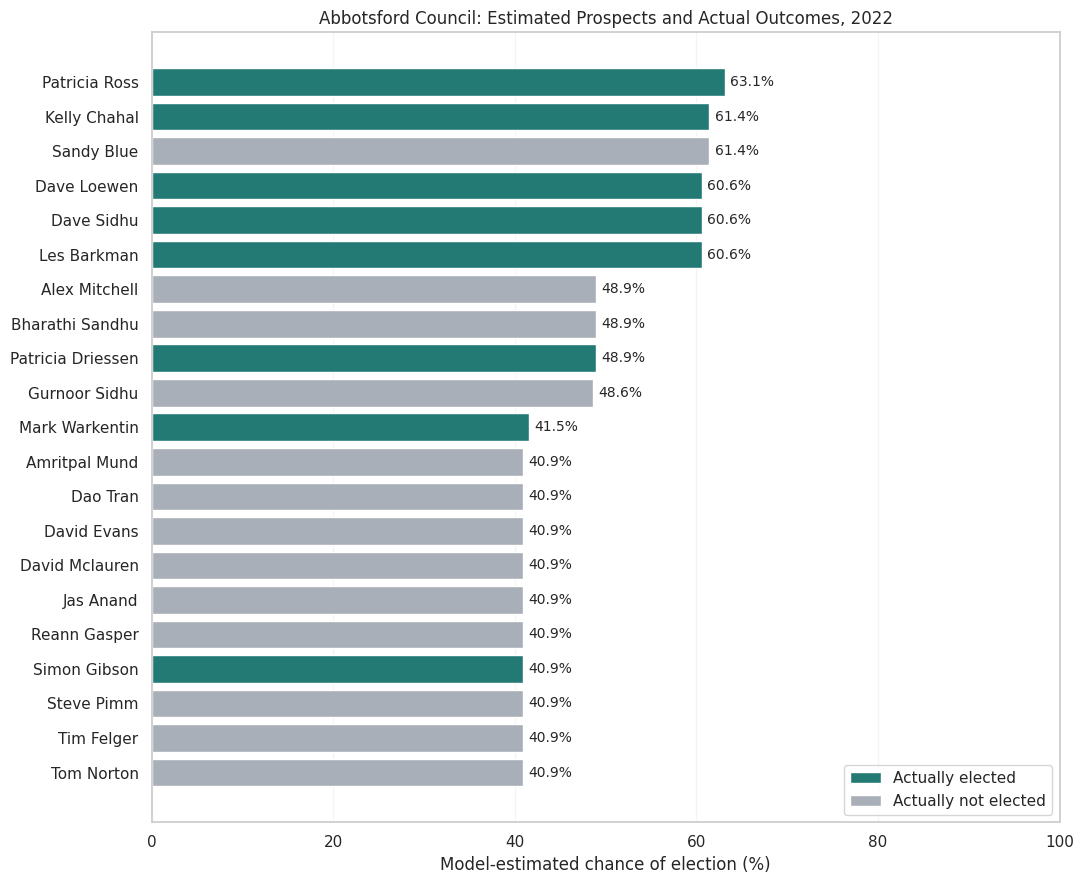

In [23]:
# Compare the estimates with the actual outcomes for the same candidates
from matplotlib.patches import Patch

plot_data = council_results.iloc[::-1]
colours = plot_data['Actual outcome'].map({'Elected': '#237A75', 'Not elected': '#A8AFB8'})
fig, ax = plt.subplots(figsize=(11, 9))
bars = ax.barh(plot_data['Candidate'], plot_data['Estimated chance (%)'], color=colours)
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=10)
ax.set_xlim(0, 100)
ax.set_xlabel('Model-estimated chance of election (%)')
ax.set_ylabel('')
ax.set_title('Abbotsford Council: Estimated Prospects and Actual Outcomes, 2022')
ax.legend(handles=[
    Patch(facecolor='#237A75', label='Actually elected'),
    Patch(facecolor='#A8AFB8', label='Actually not elected')
], loc='lower right')
ax.grid(axis='x', alpha=0.2)
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.savefig('abbotsford_candidate_prospects.png', dpi=200, bbox_inches='tight')
plt.show()


### What a Campaign Manager Can Take from This Comparison

Patricia Ross received an estimated chance of **63.1%** and was elected. Sandy Blue received **61.4%** but was not elected. Mark Warkentin received **41.5%** and was elected. The model therefore captured some outcomes and missed others. A lower estimate can flag a candidate for closer investigation, but it cannot tell a campaign manager whether extra volunteers, outreach or funding would secure a win.

Several candidates received equal estimates. The available inputs do not always distinguish candidates well, so a tie should not be interpreted as a meaningful ranking. These percentages are model estimates, not verified probability calibration, and do not need to add up to 100% in a race with multiple seats.

The same limitation is visible in the Abbotsford mayoral records: all four candidates received **36.9%**, although Ross Siemens was elected. Current polling, campaign activity and local issues would provide information that this dataset does not contain.

The table and chart above were produced from the exported candidate predictions. Running the cells again uses the current trained model and regenerates the comparison. They do not add features or change training.

## **8. Save the Final Model**

The complete pipeline is saved so the same preprocessing and model can later be loaded by a **FastAPI REST API**. The API will accept candidate and race information and return a predicted class and probability of being elected.

In [24]:
# Save the entire preprocessing and modelling pipeline
model_path = 'municipal_election_model.joblib'
joblib.dump(selected_model, model_path)

# Confirm that the saved model can be loaded and used
loaded_model = joblib.load(model_path)
sample_prediction = loaded_model.predict(X_test.head(1))[0]
sample_probability = loaded_model.predict_proba(X_test.head(1))[0, 1]

print(f'Model saved as: {model_path}')
print(f'Sample predicted class: {sample_prediction}')
print(f'Sample probability of being elected: {sample_probability:.1%}')

Model saved as: municipal_election_model.joblib
Sample predicted class: 0
Sample probability of being elected: 36.9%


## **9. Comments and Documentation**


- Missing targets, blank values, and duplicates were checked to prevent incomplete or repeated records from affecting the results.
- Only contested races were modelled, while vote totals and acclamation information were excluded, to prevent data leakage and ensure predictions were based only on information available before the election outcome.
- A preprocessing pipeline was created so missing values, numerical features, and categorical features would be handled consistently during training and future API predictions.
- Baseline models were compared with Random Forest models to determine whether a more complex model provided meaningful improvement.
- F1-score and ROC-AUC were emphasized because the target was imbalanced, while grouped cross-validation was used to prevent candidates from the same race from appearing in both training and validation data.

## **10. Deployment Service**

The trained election model is made available through a **FastAPI REST API**. The **/predict** endpoint accepts candidate and election information, applies the same preprocessing used during training, and returns the predicted outcome and probability of election in JSON format. Pydantic validation checks that submitted values use the expected data types and individual field ranges.


### Deployment Plan

The completed model and its preprocessing steps are saved together in **municipal_election_model.joblib**, so another person can use the trained pipeline without repeating the modelling process. The **app.py** file contains the FastAPI service, which loads this saved pipeline, accepts candidate information, and returns a predicted outcome and probability in JSON format. The **requirements.txt** file lists the package versions needed to run the service, while the Dockerfile packages the application, saved model, and dependencies into a consistent environment. These files should stay together when the project is transferred to another computer with a compatible Python or Docker setup. The health and prediction endpoints allow the receiving person to check that the service works. The API has been tested within this notebook using TestClient; running the Docker container still requires separate verification.


In [25]:
# Install the packages needed for the REST API
!pip -q install fastapi uvicorn httpx

In [26]:
# Import the packages required for the deployment service
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
import joblib
import pandas as pd

# Load the complete trained pipeline
deployment_model = joblib.load("municipal_election_model.joblib")

# Create the FastAPI application
app = FastAPI(
    title="Municipal Election Outcome Intelligence API",
    description="Estimates a candidate's probability of being elected.",
    version="1.0.0",
)

# Define and validate the information accepted by the API
class CandidateInput(BaseModel):
    incumbent: int = Field(ge=0, le=1)
    election_year: int = Field(ge=1867, le=2100)
    candidate_count: int = Field(ge=2)
    seats_available: int = Field(ge=1)
    candidate_to_seat_ratio: float = Field(gt=0)
    municipality: str
    party: str
    gender: str
    position: str
    ward: str
    province: str
    region: str


@app.get("/health")
def health_check():
    """Confirm that the API and model are available."""
    return {
        "status": "healthy",
        "model_loaded": True,
    }


@app.post("/predict")
def predict_election_outcome(candidate: CandidateInput):
    """Return the predicted election outcome and probability."""
    try:
        # Convert the submitted JSON information into a one-row DataFrame
        candidate_data = pd.DataFrame([candidate.model_dump()])

        # Generate the predicted class and probability
        predicted_class = int(deployment_model.predict(candidate_data)[0])
        probability_elected = float(
            deployment_model.predict_proba(candidate_data)[0, 1]
        )

        return {
            "predicted_class": predicted_class,
            "predicted_outcome": (
                "Elected" if predicted_class == 1 else "Not elected"
            ),
            "probability_elected": round(probability_elected, 4),
        }

    except Exception as error:
        raise HTTPException(
            status_code=500,
            detail=f"Prediction could not be completed: {error}",
        )


print("FastAPI deployment service created successfully.")

FastAPI deployment service created successfully.


In [27]:
# Save the same API implementation for use outside the notebook
from pathlib import Path

app_code = '''# Import the packages required for the deployment service
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
import joblib
import pandas as pd

# Load the complete trained pipeline
deployment_model = joblib.load("municipal_election_model.joblib")

# Create the FastAPI application
app = FastAPI(
    title="Municipal Election Outcome Intelligence API",
    description="Estimates a candidate's probability of being elected.",
    version="1.0.0",
)

# Define and validate the information accepted by the API
class CandidateInput(BaseModel):
    incumbent: int = Field(ge=0, le=1)
    election_year: int = Field(ge=1867, le=2100)
    candidate_count: int = Field(ge=2)
    seats_available: int = Field(ge=1)
    candidate_to_seat_ratio: float = Field(gt=0)
    municipality: str
    party: str
    gender: str
    position: str
    ward: str
    province: str
    region: str


@app.get("/health")
def health_check():
    """Confirm that the API and model are available."""
    return {
        "status": "healthy",
        "model_loaded": True,
    }


@app.post("/predict")
def predict_election_outcome(candidate: CandidateInput):
    """Return the predicted election outcome and probability."""
    try:
        # Convert the submitted JSON information into a one-row DataFrame
        candidate_data = pd.DataFrame([candidate.model_dump()])

        # Generate the predicted class and probability
        predicted_class = int(deployment_model.predict(candidate_data)[0])
        probability_elected = float(
            deployment_model.predict_proba(candidate_data)[0, 1]
        )

        return {
            "predicted_class": predicted_class,
            "predicted_outcome": (
                "Elected" if predicted_class == 1 else "Not elected"
            ),
            "probability_elected": round(probability_elected, 4),
        }

    except Exception as error:
        raise HTTPException(
            status_code=500,
            detail=f"Prediction could not be completed: {error}",
        )
'''
Path("app.py").write_text(app_code, encoding="utf-8")
print("app.py saved in:", Path("app.py").resolve().parent)


app.py saved in: /content


## **11. Deployment Testing**

The FastAPI service was tested locally within the notebook using FastAPI's TestClient. The health endpoint confirmed that the API and trained model were available. An illustrative candidate request was then submitted to the prediction endpoint. The successful HTTP status code of 200 and JSON response confirmed that the endpoint accepted the required input, applied the saved modelling pipeline, and returned a predicted outcome and probability of election.

In [28]:
# Test the API locally without starting an external server
from fastapi.testclient import TestClient

client = TestClient(app)

# Confirm that the API and model are available
health_response = client.get("/health")

print("Health status code:", health_response.status_code)
print("Health response:", health_response.json())


Health status code: 200
Health response: {'status': 'healthy', 'model_loaded': True}


In [29]:
# Submit sample candidate information to the prediction endpoint
sample_request = {
    "incumbent": 1,
    "election_year": 2022,
    "candidate_count": 4,
    "seats_available": 1,
    "candidate_to_seat_ratio": 4.0,
    "municipality": "Toronto",
    "party": "Independent",
    "gender": "M",
    "position": "Councillor",
    "ward": "1",
    "province": "ON",
    "region": "Ontario",
}

prediction_response = client.post("/predict", json=sample_request)

print("Prediction status code:", prediction_response.status_code)
print("Submitted candidate information:")
print(sample_request)
print("\nPrediction response:")
print(prediction_response.json())


Prediction status code: 200
Submitted candidate information:
{'incumbent': 1, 'election_year': 2022, 'candidate_count': 4, 'seats_available': 1, 'candidate_to_seat_ratio': 4.0, 'municipality': 'Toronto', 'party': 'Independent', 'gender': 'M', 'position': 'Councillor', 'ward': '1', 'province': 'ON', 'region': 'Ontario'}

Prediction response:
{'predicted_class': 1, 'predicted_outcome': 'Elected', 'probability_elected': 0.5232}


## **12. Containerization**

Docker can package the FastAPI service, trained model, Python runtime, and required libraries into a reproducible container. The **requirements.txt** file records the package versions needed by the application, while the Dockerfile defines how the image is assembled and how the API starts. The same deployment code shown in the Deployment Service section can be saved as **app.py** when preparing the project for containerized execution.

In [30]:
# Record the package versions used by the deployment service
from pathlib import Path

import fastapi
import joblib
import numpy
import pandas
import pydantic
import sklearn
import uvicorn

requirements_text = f"""fastapi=={fastapi.__version__}
uvicorn=={uvicorn.__version__}
pydantic=={pydantic.__version__}
pandas=={pandas.__version__}
numpy=={numpy.__version__}
scikit-learn=={sklearn.__version__}
joblib=={joblib.__version__}
"""

Path("requirements.txt").write_text(requirements_text)

print("requirements.txt contents:\n")
print(requirements_text)

requirements.txt contents:

fastapi==0.141.1
uvicorn==0.54.0
pydantic==2.13.5
pandas==2.2.3
numpy==2.1.3
scikit-learn==1.6.1
joblib==1.6.0



In [31]:
# Define the instructions used to build the Docker image
dockerfile_text = """FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt .

RUN pip install --no-cache-dir -r requirements.txt

COPY municipal_election_model.joblib .
COPY app.py .

EXPOSE 8000

CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
"""

Path("Dockerfile").write_text(dockerfile_text)

print("Dockerfile contents:\n")
print(dockerfile_text)

Dockerfile contents:

FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt .

RUN pip install --no-cache-dir -r requirements.txt

COPY municipal_election_model.joblib .
COPY app.py .

EXPOSE 8000

CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]



### Dockerfile Explanation

- `FROM python:3.11-slim` selects a lightweight Python environment.
- `WORKDIR /app` creates the working directory inside the image.
- `COPY requirements.txt .` adds the dependency list.
- `RUN pip install --no-cache-dir -r requirements.txt` installs the required Python packages.
- `COPY municipal_election_model.joblib .` adds the trained model.
- `COPY app.py .` adds the FastAPI deployment service.
- `EXPOSE 8000` identifies the port used by the API.
- `CMD` starts the FastAPI application with Uvicorn when the container launches.

The image can be built with **docker build -t municipal-election-api .** and started with **docker run -p 8000:8000 municipal-election-api**. Docker execution could not be completed locally because the available Windows environments encountered a WSL service failure. However, the required REST API was successfully tested directly within the notebook.

In [32]:
# Package the deployment files and instructions for handover
from pathlib import Path
from zipfile import ZipFile, ZIP_DEFLATED

readme_text = '### Deployment Plan\n\nThe completed model and its preprocessing steps are saved together in `municipal_election_model.joblib`, so another person can use the trained pipeline without repeating the modelling process. The `app.py` file contains the FastAPI service, which loads this saved pipeline, accepts candidate information, and returns a predicted outcome and probability in JSON format. The `requirements.txt` file lists the package versions needed to run the service, while the Dockerfile packages the application, saved model, and dependencies into a consistent environment. These files should stay together when the project is transferred to another computer with a compatible Python or Docker setup. The health and prediction endpoints allow the receiving person to check that the service works. The API has been tested within this notebook using TestClient; running the Docker container still requires separate verification.\n'
Path("README.md").write_text(readme_text, encoding="utf-8")

handover_files = [
    "municipal_election_model.joblib",
    "app.py",
    "requirements.txt",
    "Dockerfile",
    "README.md",
]
missing_files = [name for name in handover_files if not Path(name).is_file()]
if missing_files:
    raise FileNotFoundError(f"Run the model export and deployment cells first: {missing_files}")

with ZipFile("municipal-election-api.zip", "w", ZIP_DEFLATED) as handover_zip:
    for name in handover_files:
        handover_zip.write(name, arcname=name)

print("Handover package ready:", Path("municipal-election-api.zip").resolve())
print("Download this ZIP from the notebook Files panel.")


Handover package ready: /content/municipal-election-api.zip
Download this ZIP from the notebook Files panel.


## **13. Conclusion**

This notebook developed an **end-to-end binary classification workflow** that estimates a candidate’s probability of being elected in a contested Canadian municipal race. The process included data acquisition, cleaning, exploratory analysis, leakage prevention, feature engineering, model comparison, optimization, and final model selection. Limiting the analysis to contested races and excluding vote results and acclamation information helped ensure that predictions were based only on information that could reasonably be known before an election.

The final pipeline was deployed through a **FastAPI REST API** and successfully tested within the notebook. The prediction endpoint accepted candidate and election information and returned the predicted outcome and **probability of election in JSON format**. A **requirements.txt** file and Dockerfile were also prepared to support reproducible containerization in a compatible Docker environment.

The completed system demonstrates how historical information can support **candidate competitiveness analysis, campaign planning, and election research**. The same analytical process may also be transferable to organizational candidate-selection problems, such as promotions or internal recognition, but those applications would require appropriate employee data and a separately trained model. The results should support informed judgment rather than be treated as a guaranteed prediction because historical data cannot capture every political, social, or local factor that influences an election.